# Week 2 - Syntax Summary

Content covered:
1. Visualisation,
2. functions, and
3. grouping tables.

**Every cell here runs on its own - the data is built in the notebook rather than
loaded from a file, so you can edit it and re-run to see what happens.**

The point is for you to: 
1. Read the output,
2. then break something deliberately.
3. Learn how it works

**Chapters 7 to 8.4 of the textbook.**


In [1]:
# Run this cell first - the install takes about a minute
%pip install -q urllib3<2.0 datascience ipywidgets

try:
    import pyodide_http
    pyodide_http.patch_all()
except ImportError:
    pass

from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

The system cannot find the file specified.


Note: you may need to restart the kernel to use updated packages.


---

## Contents

1. [Choosing a plot](#1)
2. [Line and scatter plots](#2)
3. [Bar charts](#3)
4. [Histograms and the area principle](#4)
5. [Writing functions](#5)
6. [`apply`](#6)
7. [`group`](#7)
8. [Cross-classifying: `group` on two columns, and `pivot`](#8)
9. [`join`](#9)
10. [Quick reference](#10)


---

<a id='1'></a>
## 1. Choosing a plot

The plot you need depends on how many variables you have and whether each one is
**numerical** or **categorical**.

| What you have | Plot | Method |
|---|---|---|
| One categorical variable | Bar chart | `.barh(labels)` |
| One numerical variable | Histogram | `.hist(column, bins=...)` |
| Two numerical, x is ordered | Line | `.plot(x, y)` |
| Two numerical, x is not ordered | Scatter | `.scatter(x, y)` |
| One categorical, one numerical | Bar chart | `.barh(labels, values)` |

A column of numbers is not automatically numerical. Postal codes, years used as
labels, and ID numbers are all categorical - averaging them would be meaningless.


In [2]:
# A small table we will reuse. Age is numerical, Studio is categorical.
movies = Table().with_columns(
    'Title',   make_array('Star Wars', 'Avatar', 'Titanic', 'Jaws', 'ET', 'Jurassic Park'),
    'Studio',  make_array('Fox', 'Fox', 'Paramount', 'Universal', 'Universal', 'Universal'),
    'Year',    make_array(1977, 2009, 1997, 1975, 1982, 1993),
    'Millions', make_array(3068, 890, 1270, 1170, 1330, 1140))
movies

Title,Studio,Year,Millions
Star Wars,Fox,1977,3068
Avatar,Fox,2009,890
Titanic,Paramount,1997,1270
Jaws,Universal,1975,1170
ET,Universal,1982,1330
Jurassic Park,Universal,1993,1140


---

<a id='2'></a>
## 2. Line and scatter plots

Both take two numerical columns. The difference is whether the x values have a
natural order.

`.plot(x, y)` joins the points with a line, which says "as x increases, y does
this". Only use it when x is ordered - time, age, position.

`.scatter(x, y)` draws unconnected points. Use it when x has no order.

------
### The table below is Population (Millions) by Age (years).
#### Age is ordered, so a line makes sense

In [3]:
population = Table().with_columns(
    'Age (years)',        np.arange(0, 91, 10),
    'Population (Millions)',   make_array(3.9, 4.2, 4.4, 4.5, 4.1, 4.3, 3.6, 2.4, 1.3, 0.4))
population

Age (years),Population (Millions)
0,3.9
10,4.2
20,4.4
30,4.5
40,4.1
50,4.3
60,3.6
70,2.4
80,1.3
90,0.4


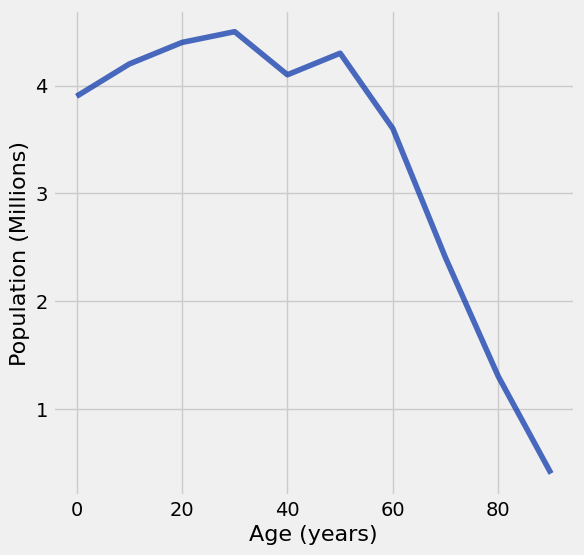

In [4]:
population.plot('Age (years)', 'Population (Millions)')

---
### The same data as a scatter is correct, but the trend is harder to follow

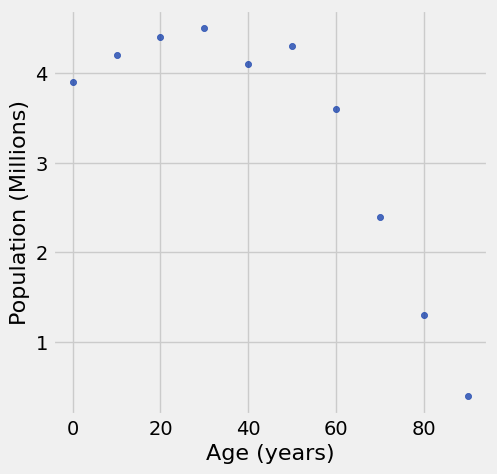

In [5]:
population.scatter('Age (years)', 'Population (Millions)')

---
### Example 2 
#### Actors have no natural order, so joining them with a line plot produces a mess.
#### - We start with the table below

In [6]:
actors = Table().with_columns(
    'Actor',      make_array('Harrison Ford', 'Samuel Jackson', 'Morgan Freeman',
                             'Tom Hanks', 'Robert Downey Jr', 'Eddie Murphy'),
    'Movies',     make_array(41, 69, 61, 44, 53, 38),
    'Total Gross', make_array(4871, 4772, 4468, 4340, 3947, 3810))
actors

Actor,Movies,Total Gross
Harrison Ford,41,4871
Samuel Jackson,69,4772
Morgan Freeman,61,4468
Tom Hanks,44,4340
Robert Downey Jr,53,3947
Eddie Murphy,38,3810


#### Wrong Approach: Movies is not an ordered sequence, so the line plot() is meaningless

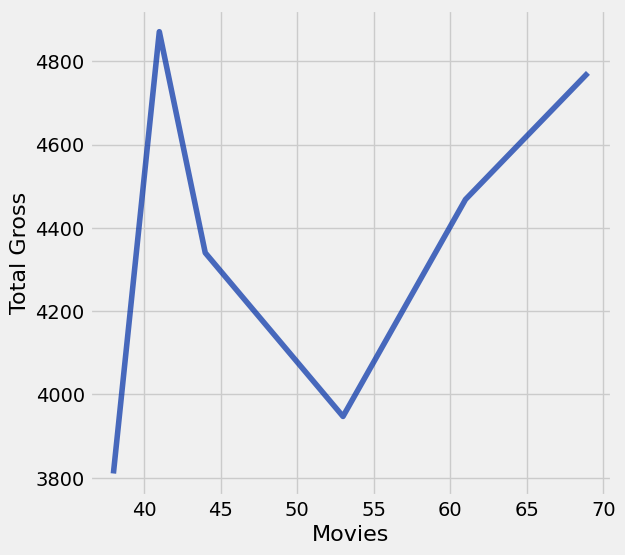

In [7]:
actors.plot('Movies', 'Total Gross')

#### Right Approach: using a .scatter() plot the relationship between Movies & Total Gross is now readable

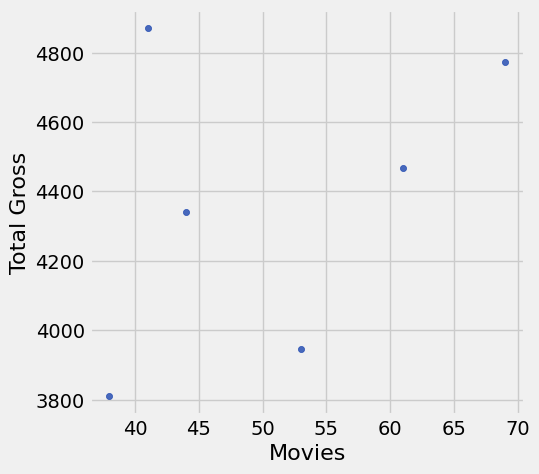

In [8]:
actors.scatter('Movies', 'Total Gross')

> **Investigate anomalies.** A single point far from the rest is usually worth
> chasing down. In the real `actors.csv`, one actor has a very high average per
> movie - because they were in only a handful of enormously successful films.
> `.where(column, are.above(value))` is how you find out who.


---

<a id='3'></a>
## 3. Bar charts

`.barh(labels)` on a table produced by `.group()` shows how many rows fall into
each category.

`.barh(labels, values)` shows one numerical value per category.

Sorting first almost always makes the chart easier to read.


### Lets look at the movies table created earlier

In [9]:
movies

Title,Studio,Year,Millions
Star Wars,Fox,1977,3068
Avatar,Fox,2009,890
Titanic,Paramount,1997,1270
Jaws,Universal,1975,1170
ET,Universal,1982,1330
Jurassic Park,Universal,1993,1140


### Lets ask a question: How many of these films did each studio make?
#### We can use .group() to help us count how many times each studio produced a film
#### - Studio is a categorical variable
#### - We count how many times each category appears

In [10]:
movies.group('Studio')

Studio,count
Fox,2
Paramount,1
Universal,3


#### We can now plot a horizontal bar graph for each category 

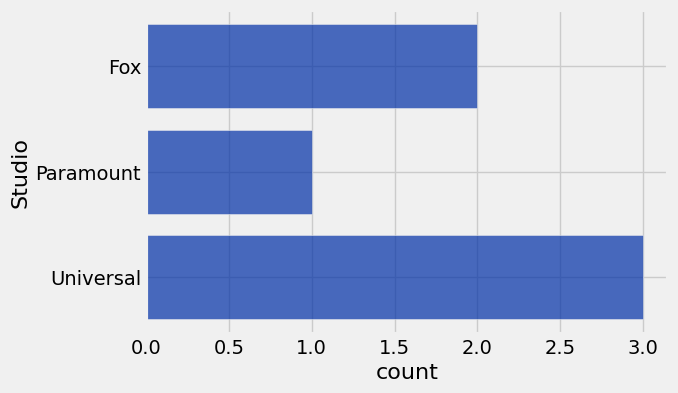

In [11]:
movies.group('Studio').barh('Studio')

### Sorting the grouped data makes it much easier to compare

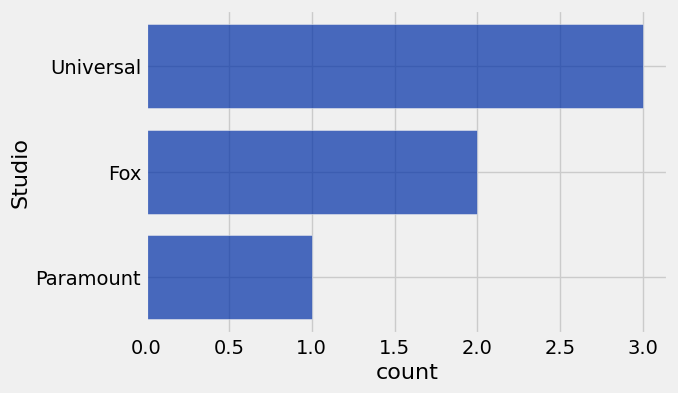

In [12]:
movies.group('Studio').sort('count', descending=True).barh('Studio')

### Question: How much revenue did each film generate
#### - Plot a bar chart, One bar per film, vs revenue (millions)

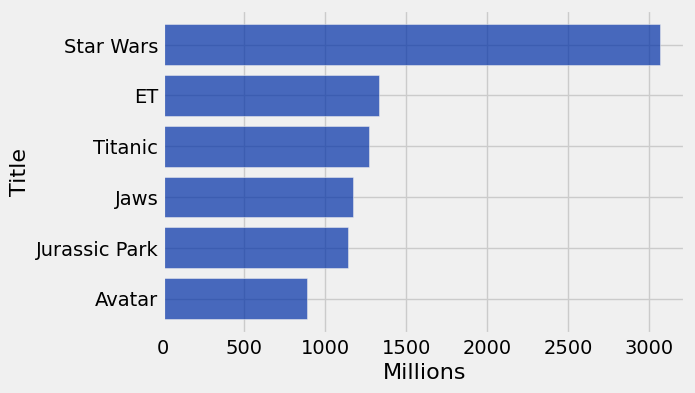

In [13]:
movies.sort('Millions', descending=True).barh('Title', 'Millions')

> **Titles matter.** A plot without a title makes the reader work out what they
> are looking at. Add one with `plots.title(...)` immediately after the plotting
> call, and say what the chart *shows*, not what it *is* - "Box office declines
> sharply after the top three" beats "Bar chart of millions".
>
> `plots.title("Bar chart of millions")`


---

<a id='4'></a>
## 4. Histograms and the area principle

A histogram shows the distribution of **one numerical variable**. Values are
grouped into **bins**, and each bar covers a range rather than a single value.

```
tbl.hist(column, bins = np.arange(start, stop, step), unit = 'Year')
```

Bins can also be uneven, using `make_array`.


---
## How old are these films, in 2025?

In [14]:
ages = 2025 - movies.column('Year')
movies = movies.with_column('Age', ages)
movies.select('Title', 'Age')

Title,Age
Star Wars,48
Avatar,16
Titanic,28
Jaws,50
ET,43
Jurassic Park,32


### Even bins: every bar is 10 years wide

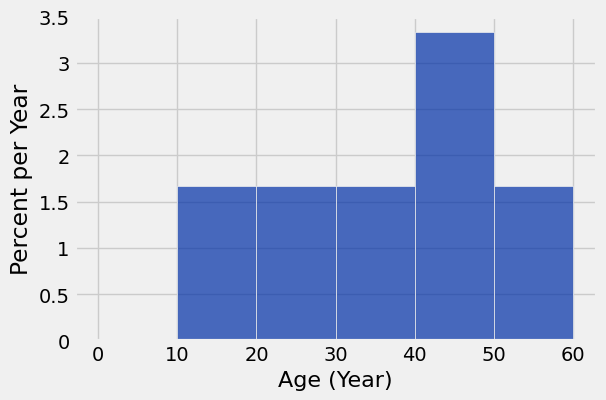

In [15]:
movies.hist('Age', bins = np.arange(0, 61, 10), unit = 'Year')

### Uneven bins: narrow where the data is dense, wide where it is sparse

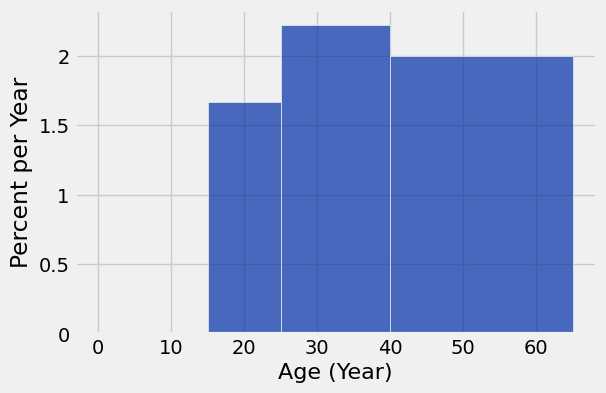

In [16]:
my_bins = make_array(0, 5, 10, 15, 25, 40, 65)
movies.hist('Age', bins = my_bins, unit = 'Year')

### The area principle

**The y-axis is not a count.** It is *percent per unit* - density. What tells you
how much data is in a bin is the **area** of the bar: height × width.

This is why a wide, short bar can contain more data than a narrow, tall one.

$$\text{height} = \frac{\text{percent in bin}}{\text{width of bin}}
\qquad\qquad
\text{percent in bin} = \text{height} \times \text{width}$$

`.bin()` gives you the counts, so you can check this yourself.


In [17]:
binned_data = movies.bin('Age', bins = my_bins)
binned_data

bin,Age count
0,0
5,0
10,0
15,1
25,2
40,3
65,0


### Convert counts to percentages of all rows

In [18]:
binned_data = binned_data.with_column(
    'Percent', 100 * binned_data.column('Age count') / movies.num_rows)
binned_data

bin,Age count,Percent
0,0,0
5,0,0
10,0,0
15,1,16.6667
25,2,33.3333
40,3,50
65,0,0


### The last row of .bin() is the right edge of the final bin, with count 0.
### - Drop it, then np.diff gives the width of each remaining bin.

In [19]:
height_table = binned_data.take(np.arange(binned_data.num_rows - 1))
bin_widths = np.diff(binned_data.column('bin'))

height_table = height_table.with_column('Width', bin_widths)
height_table = height_table.with_column(
    'Height', height_table.column('Percent') / height_table.column('Width'))
height_table

bin,Age count,Percent,Width,Height
0,0,0,5,0
5,0,0,5,0
10,0,0,5,0
15,1,16.6667,10,1.66667
25,2,33.3333,15,2.22222
40,3,50,25,2


Compare the `Height` column above with the bars in the histogram - they match.

> **Common mistake.** Reading a histogram as though the tallest bar has the most
> data. With uneven bins that is often false. Multiply height by width before
> comparing bins.


---

<a id='5'></a>
## 5. Writing functions

```
def name(argument):
    """Documentation: what this does."""
    body
    return value
```

Four things to get right:

- **`def`** starts the definition; the line ends with a colon
- the **body is indented** - Python uses indentation, not brackets
- **`return`** hands a value back to whoever called the function
- the **docstring** in triple quotes says what it does


In [20]:
def triple(x):
    """Triples the input."""
    tripled_x = x * 3
    return tripled_x

triple(3)

9

### The argument can be a name, an expression, an array, even a string

In [21]:
num = 4
print(triple(num))
print(triple(num * 5))
print(triple(np.arange(4)))
print(triple('ha'))

12
60
[0 3 6 9]
hahaha


### `return` is not `print`

`print` shows a value on the screen. `return` sends it back so it can be stored
or used. A function without `return` gives back `None`, silently.


In [22]:
def double_print(x):
    print(x * 2)          # shows it, gives back nothing

def double_return(x):
    return x * 2          # hands the value back

a = double_print(5)
b = double_return(5)
print('from print:', a)   # None -- the value was displayed, not returned
print('from return:', b)

10
from print: None
from return: 10


### Two arguments, and a string built from both

In [23]:
def name_and_age(name, year):
    """Returns a sentence stating how old someone born in `year` is."""
    age = 2025 - year
    return name + ' is ' + str(age) + ' years old.'

name_and_age('Thandi', 1999)

'Thandi is 26 years old.'

---

<a id='6'></a>
## 6. `apply`

`.apply(function, column)` runs a function on **every** value in a column and
returns an array of the results. It does not change the table.

Pass the function **without brackets** - you are giving `apply` the function
itself, not calling it.


In [24]:
fam = Table().with_columns(
    'First Name', make_array('Thandi', 'Sipho', 'Naledi', 'Kagiso'),
    'Birth Year', make_array(1999, 1985, 2003, 1972))
fam

First Name,Birth Year
Thandi,1999
Sipho,1985
Naledi,2003
Kagiso,1972


In [25]:
def age(year):
    """How old someone born in `year` turns in 2025."""
    return 2025 - year

fam.apply(age, 'Birth Year')

array([26, 40, 22, 53])

### Two columns -> a function that takes two arguments, in that order

In [26]:
fam.apply(name_and_age, 'First Name', 'Birth Year')

array(['Thandi is 26 years old.', 'Sipho is 40 years old.',
       'Naledi is 22 years old.', 'Kagiso is 53 years old.'],
      dtype='<U23')

### apply returns an array, so it can become a new column

In [27]:
fam.with_column('Statement', fam.apply(name_and_age, 'First Name', 'Birth Year'))

First Name,Birth Year,Statement
Thandi,1999,Thandi is 26 years old.
Sipho,1985,Sipho is 40 years old.
Naledi,2003,Naledi is 22 years old.
Kagiso,1972,Kagiso is 53 years old.


> **Common mistake.** Writing `fam.apply(age(), 'Birth Year')`. The brackets call
> the function immediately, before `apply` ever sees it. Leave them off.


---

<a id='7'></a>
## 7. `group`

`.group(column)` counts how many rows share each value. The result always has a
column named `count`.

`.group(column, function)` instead applies a function to every other column,
one group at a time.


### Lets create a table to work with

In [28]:
cones = Table().with_columns(
    'Flavor', make_array('strawberry', 'chocolate', 'chocolate', 'strawberry',
                         'chocolate', 'bubblegum'),
    'Color',  make_array('pink', 'light brown', 'dark brown', 'pink',
                         'dark brown', 'pink'),
    'Price',  make_array(3.55, 4.75, 5.25, 5.25, 5.25, 4.75))
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


### How many cones of each flavour?

In [29]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


### Average of every other column, per flavour.
### - Color is text, so its average is blank -- that is expected.

In [30]:
cones.group('Flavor', np.average)

Flavor,Color average,Price average
bubblegum,,4.75
chocolate,,5.08333
strawberry,,4.4


### Drop the text column first for a cleaner result

In [31]:
cones.drop('Color').group('Flavor', np.average)

Flavor,Price average
bubblegum,4.75
chocolate,5.08333
strawberry,4.4


> **Two things to watch.** `group` **renames** the aggregated column - `Price`
> becomes `Price average`. And it returns rows in **alphabetical** order of the
> grouping column, not the original order. Check before using `.item()` on the
> result.


---

<a id='8'></a>
## 8. Cross-classifying: `group` on two columns, and `pivot`

Both answer the same question - how do two categorical variables combine? - but
they lay the answer out differently.

**`group([col1, col2])`** gives one row per combination. Long and narrow.

**`pivot(col1, col2)`** gives a grid: `col1` becomes the column headers, `col2`
the row labels. Wide, and easier to read across.


In [32]:
cones.group(['Flavor', 'Color'])

Flavor,Color,count
bubblegum,pink,1
chocolate,dark brown,2
chocolate,light brown,1
strawberry,pink,2


In [33]:
cones.pivot('Flavor', 'Color')

Color,bubblegum,chocolate,strawberry
dark brown,0,2,0
light brown,0,1,0
pink,1,0,2


`pivot` also takes `values` and `collect`, to fill the grid with something other
than a count:

```
tbl.pivot(columns, rows, values = 'Price', collect = np.average)
```


In [34]:
cones.pivot('Flavor', 'Color', values = 'Price', collect = np.average)

Color,bubblegum,chocolate,strawberry
dark brown,0,5.25,0
light brown,0,4.75,0
pink,4.75,0,4.4


### When to use which

`pivot` is the better choice when you want to **compare two groups directly** -
because they end up side by side as columns, so you can subtract them.


### Tallest building of each material, in each city

In [35]:
buildings = Table().with_columns(
    'city',     make_array('Chicago', 'Chicago', 'Chicago', 'New York',
                           'New York', 'New York', 'Durban', 'Durban'),
    'material', make_array('steel', 'concrete', 'steel', 'concrete',
                           'steel', 'concrete', 'concrete', 'steel'),
    'height',   make_array(442, 423, 346, 541, 319, 381, 152, 106))
buildings

city,material,height
Chicago,steel,442
Chicago,concrete,423
Chicago,steel,346
New York,concrete,541
New York,steel,319
New York,concrete,381
Durban,concrete,152
Durban,steel,106


### group: one row per (city, material) pair

In [36]:
buildings.group(['city', 'material'], max)

city,material,height max
Chicago,concrete,423
Chicago,steel,442
Durban,concrete,152
Durban,steel,106
New York,concrete,541
New York,steel,319


### pivot: materials become columns, so they sit side by side

In [37]:
tallest = buildings.pivot('material', 'city', values = 'height', collect = max)
tallest

city,concrete,steel
Chicago,423,442
Durban,152,106
New York,541,319


### Because they are columns, subtracting them is a single step

In [38]:
tallest = tallest.with_column(
    'difference', abs(tallest.column('steel') - tallest.column('concrete')))
tallest.sort('difference', descending = True)

city,concrete,steel,difference
New York,541,319,222
Durban,152,106,46
Chicago,423,442,19


Doing that from the `group` version would mean pulling rows out one at a time.
When the next step is arithmetic *between* the groups, pivot first.


---

<a id='9'></a>
## 9. `join`

`.join(own_column, other_table, other_column)` combines two tables by matching
values. The columns can have different names - that is what the third argument
is for.


In [39]:
drinks = Table().with_columns(
    'Drink', make_array('Milk Tea', 'Espresso', 'Latte', 'Espresso'),
    'Cafe',  make_array('Asha', 'Strada', 'Strada', 'FSM'),
    'Price', make_array(5.5, 1.75, 3.25, 2.0))
drinks

Drink,Cafe,Price
Milk Tea,Asha,5.5
Espresso,Strada,1.75
Latte,Strada,3.25
Espresso,FSM,2


In [40]:
discounts = Table().with_columns(
    'Coupon',   make_array('10%', '25%', '5%'),
    'Location', make_array('Asha', 'Strada', 'Asha'))
discounts

Coupon,Location
10%,Asha
25%,Strada
5%,Asha


### Match drinks.Cafe against discounts.Location

In [41]:
drinks.join('Cafe', discounts, 'Location')

Cafe,Drink,Price,Coupon
Asha,Milk Tea,5.5,10%
Asha,Milk Tea,5.5,5%
Strada,Espresso,1.75,25%
Strada,Latte,3.25,25%


Look carefully at what happened:

- **FSM has vanished.** It appears in `drinks` but not in `discounts`, so it is
  dropped. This is an *inner* join - rows without a match on both sides disappear,
  with no warning.
- **Asha appears twice.** It has two coupons, so every Asha drink is paired with
  each of them.

Swapping which table you start from changes the column order, but the matching
is the same.


In [42]:
discounts.join('Location', drinks, 'Cafe')

Location,Coupon,Drink,Price
Asha,10%,Milk Tea,5.5
Asha,5%,Milk Tea,5.5
Strada,25%,Espresso,1.75
Strada,25%,Latte,3.25


> **Common mistake.** Assuming `join` keeps everything, like a spreadsheet lookup
> that leaves blanks. It does not. Compare `num_rows` before and after - if rows
> went missing, that is why.


---

<a id='10'></a>
## 10. Quick reference

### Plotting

| Call | Shows |
|---|---|
| `tbl.plot(x, y)` | Line - only when x is ordered |
| `tbl.scatter(x, y)` | Scatter - two numerical variables |
| `tbl.barh(labels)` | Bar chart of counts, after `.group()` |
| `tbl.barh(labels, values)` | Bar chart of one numerical column |
| `tbl.hist(col, bins=..., unit=...)` | Histogram of one numerical variable |
| `tbl.bin(col, bins=...)` | The counts behind a histogram, as a table |

### Functions

| Call | Does |
|---|---|
| `def f(x):` … `return y` | Defines a function |
| `tbl.apply(f, col)` | Runs `f` on every value, returns an array |
| `tbl.apply(f, col1, col2)` | Runs a two-argument `f` down both columns |

### Grouping and combining

| Call | Returns |
|---|---|
| `tbl.group(col)` | One row per value, with a `count` column |
| `tbl.group(col, fn)` | One row per value, `fn` applied to other columns |
| `tbl.group([c1, c2])` | One row per combination - long |
| `tbl.pivot(cols, rows)` | A grid of counts - wide |
| `tbl.pivot(cols, rows, values, collect)` | A grid of aggregated values |
| `tbl.join(own, other_tbl, theirs)` | Matched rows from both - unmatched dropped |

### Common sources of errors

| | |
|---|---|
| Histogram y-axis | Density, not count. Area = percent. |
| `group` column names | `Price` becomes `Price average` |
| `group` row order | Alphabetical, not original |
| `apply` | Pass `f`, not `f()` |
| A function with no `return` | Gives back `None` |
| `join` | Inner join - unmatched rows disappear |
| `.bin()` last row | Right edge of the final bin, count 0 |

---

### Sources

- [Chapter 7 - Visualization](https://inferentialthinking.com/chapters/07/Visualization.html)
- [Chapter 7.1 - Numerical distributions](https://inferentialthinking.com/chapters/07/1/Visualizing_Numerical_Distributions.html)
- [Chapter 7.2 - Categorical distributions](https://inferentialthinking.com/chapters/07/2/Visualizing_Categorical_Distributions.html)
- [Chapter 8 - Functions and Tables](https://inferentialthinking.com/chapters/08/Functions_and_Tables.html)
- [Chapter 8.1 - Applying a function to a column](https://inferentialthinking.com/chapters/08/1/Applying_a_Function_to_a_Column.html)
- [Chapter 8.2 - Classifying by one variable](https://inferentialthinking.com/chapters/08/2/Classifying_by_One_Variable.html)
- [Chapter 8.3 - Cross-classifying](https://inferentialthinking.com/chapters/08/3/Cross-Classifying_by_More_than_One_Variable.html)
- [Chapter 8.4 - Joining tables by columns](https://inferentialthinking.com/chapters/08/4/Joining_Tables_by_Columns.html)
